# Буткемп, день 9 — календарные спреды в низкочастотной торговле

День 9 — про **calendar spread**: один и тот же товар, две даты поставки, а связь между ними задаёт само
время. Эдж здесь медленный, а данных мало: «The hard part is not speed, it is believing a pattern you
have seen fifteen times». Сегодня мы пишем спред через **carry** — стоимость переноса, ограниченную с
одной стороны арбитражем, а с другой — convenience yield, — а потом торгуем его тем же движком, что и в
день 8, и считаем, сколько вариантов перебрали.

## Что задано и какие данные нам выдали

Слайд «TODAY'S TASK» просит для одного сторабельного товара:

1. **Curve and carry** — построить кривую на нескольких датах, посчитать implied carry и implied
   convenience yield при предполагаемых $r$ и $u$, измерить расстояние до full-carry cap.
2. **The spread series** — фиксированная пара контрактов в долларах, с явным роллом, а не naive
   front-pair splice.
3. **Trade it** — прогнать движок дня 8 (z-score с гистерезисом, `shift(1)`, издержки на две ноги,
   flat до notice-даты) и разобрать хвосты long против short.
4. **Seasonality** — гармонический профиль expanding-window против whole-sample, Sharpe у каждого с
   интервалом, и no-seasonality контроль.
5. **Risk and exposure** — outright delta спреда, волатильность по удалённости от экспирации
   (Samuelson), худшие сделки.
6. **Judge it** — посчитанные trials, held-out финальный период, честный вывод.

Файл один — `~/Downloads/dfs.pickle`, `pickle` с `dict` по 44 товарным символам. У каждого символа —
дневной индекс и ряды с колонками `Close, Close_n, Premium`. Ключи двух видов: `base_1..base_6`
(серии по зрелости, `base_1` — ближний) и буквенные `F_1..Z_1` (календарные месяцы поставки:
`F`=январь, `G`=февраль, … `Z`=декабрь; `_2` — следующий год).

Берём сторабельный товар с жидкой кривой — **crude oil `CL.NYMEX`**, пару соседних месяцев
**`F_1` (январь) − `G_1` (февраль)**. Нефть сторабельная (её можно держать в танках), кривая у неё
исторически и в contango, и в backwardation, а январь–февраль — тот участок кривой, где зимняя
отопительная seasonality наибольшая, так что материал для пункта 4 есть. Всюду ниже цена `CL` —
доллары за баррель, контракт — 1000 баррелей, поэтому денежный спред это $\Delta \times 1000$.

**Первая оговорка, и она важная.** В выгрузке **нет дат экспирации и notice**, и нет истинных
фиксированных контрактов вроде «Dec-2020», которые жили бы от листинга до поставки. Ряды `F_1..Z_1` —
это **константно-матурностные (generic) серии по календарному месяцу**: `F_1` всегда «январский
контракт», и когда старый январский истекает, ряд переключается на следующий январский. Это видно по тому, что `base_1` (ближняя серия) в каждый день в точности совпадает с одним из буквенных рядов
(проверим это ниже кодом), — то есть буквенные ряды построены роллом по экспирации, а не как отдельные
контракты. Из этого следует, что требование слайда «fixed pair over its life» строго не воспроизводится:
у нас нет двух конкретных контрактов, которые мы могли бы держать вместе от листинга до поставки. Хуже
того, даже «пара соседних месяцев» остаётся одним инструментом не весь год: январский контракт CL
истекает ~19 декабря, февральский — ~21 января, и между этими датами `F_1` уже «следующий январь», а
`G_1` ещё «текущий февраль» — разрыв в 11 месяцев вместо одного. Мы честно назовём это ограничением,
покажем, чем splice generic-ряда опасен (на иллюстрации слайда 32), и построим спред так, чтобы не
выдать generic-ряд за фиксированный контракт: торговать пару только внутри её жизни, а в окне между
экспирациями ног стоять flat.

## Окружение

Импортируем нужное, фиксируем seed и настраиваем вывод, чтобы все числа ниже воспроизводились при
повторном прогоне.

In [1]:
import os, pickle, warnings
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, kpss
from scipy.stats import norm
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
pd.set_option('display.width', 170)
pd.set_option('display.max_columns', 40)
plt.rcParams.update({'figure.figsize': (11, 3.4), 'figure.dpi': 110, 'axes.grid': True,
                     'grid.alpha': .3, 'axes.spines.top': False, 'axes.spines.right': False})
RNG_SEED = 20251008
DATA = os.path.expanduser('~/Downloads/dfs.pickle')

SYM   = 'CL.NYMEX'   # crude oil, сторабельный товар
NEAR  = 'F_1'        # январский generic
FAR   = 'G_1'        # февральский generic
MULT  = 1000.0       # $/bbl * 1000 баррелей = $ на пару
COST  = 20.0         # издержки ОДНОЙ стороны (вход ИЛИ выход) на обе ноги пары; круг = 2×COST = $40
print('товар:', SYM, ' пара:', NEAR, '-', FAR)

товар: CL.NYMEX  пара: F_1 - G_1


## Разведка данных

Прежде чем что-то считать, посмотрим, что лежит в выгрузке: сколько ряды, за какой период, что означают
ключи, и — главное — правда ли, что `base_1` совпадает с буквенным рядом (это и есть доказательство
generic-природы буквенных серий). Минимальную разведку делаем на коротком окне, агрегаты потом считаем
по полному периоду.

In [2]:
obj = pickle.load(open(DATA, 'rb'))
print('всего символов:', len(obj))
d = obj[SYM]
letters = [k for k in d if not k.startswith('base')]
print(SYM, 'ключей:', len(d), '| буквенных:', len(letters))
print('ключи:', list(d.keys()))
b1 = d['base_1']['Close'].dropna()
print('base_1: n=%d  %s .. %s' % (len(b1), b1.index.min().date(), b1.index.max().date()))
print('колонки:', list(d['base_1'].columns))
F = d[NEAR]['Close'].dropna(); G = d[FAR]['Close'].dropna()
print('F_1: n=%d  %s .. %s' % (len(F), F.index.min().date(), F.index.max().date()))
print('G_1: n=%d  %s .. %s' % (len(G), G.index.min().date(), G.index.max().date()))

всего символов: 44
CL.NYMEX ключей: 30 | буквенных: 24
ключи: ['base_1', 'base_2', 'base_3', 'base_4', 'base_5', 'base_6', 'F_1', 'F_2', 'G_1', 'G_2', 'H_1', 'H_2', 'J_1', 'J_2', 'K_1', 'K_2', 'M_1', 'M_2', 'N_1', 'N_2', 'Q_1', 'Q_2', 'U_1', 'U_2', 'V_1', 'V_2', 'X_1', 'X_2', 'Z_1', 'Z_2']
base_1: n=10550  1983-03-30 .. 2025-03-04
колонки: ['Close', 'Close_n', 'Premium']
F_1: n=10443  1983-06-01 .. 2025-03-04
G_1: n=10386  1983-06-23 .. 2025-03-04


In [3]:
# Доказательство generic-природы: base_1 каждый день равен одному из буквенных рядов.
front = pd.Series(index=b1.index, dtype=object)
for c in [k[:-2] for k in d if k.endswith('_1') and not k.startswith('base')]:
    eq = (b1 - d[c + '_1']['Close'].reindex(b1.index)).abs() < 1e-6
    front[eq.fillna(False)] = c
print('base_1 объясняется буквенными рядами на %.1f%% дней' % (front.notna().mean() * 100))
sw = front.dropna(); sw = sw[sw != sw.shift()]
print('переключений переднего контракта за историю: %d' % len(sw))
print('последние переключения:', [(str(i.date()), v) for i, v in sw.tail(4).items()])
print('на 2020-06-01 CL: base_1..6 =', [round(d['base_%d' % k]['Close'].loc['2020-06-01'], 2) for k in range(1, 7)])

base_1 объясняется буквенными рядами на 100.0% дней
переключений переднего контракта за историю: 798
последние переключения: [('2024-11-18', 'F'), ('2024-12-17', 'G'), ('2025-01-20', 'H'), ('2025-02-19', 'J')]
на 2020-06-01 CL: base_1..6 = [np.float64(35.44), np.float64(35.79), np.float64(36.17), np.float64(36.4), np.float64(36.65), np.float64(36.9)]


`base_1` объясняется буквенными рядами на 100% дней, и передний ряд переключается сотни раз за
историю — значит, буквенные серии построены **роллом по экспирации** и представляют календарный месяц
поставки, а не конкретный контракт. Заодно видно, что `base_1..6` в один день дают разные уровни
(35.44, 35.79, 36.17, … — это точки кривой forward), а не сдвиги одной серии.

Разложим кривую по нескольким датам: две даты растут с удалением поставки (contango: 2020-06-01 и
2015-06-01 с плоским, но растущим ближним участком), и на двух ближний участок падает (2000-06-01,
2025-03-04). Форма кривой важна: **implied carry меняет знак**, и это наблюдаемый факт, а не
допущение.

In [4]:
for dt in ['2020-06-01', '2015-06-01', '2000-06-01', '2025-03-04']:
    dt = pd.Timestamp(dt)
    row = {k: round(float(d[k]['Close'].loc[dt]), 2) for k in
           ['F_1', 'G_1', 'H_1', 'J_1', 'K_1', 'M_1'] if dt in d[k]['Close'].index}
    shape = 'contango' if row['H_1'] > row['F_1'] else 'backwardation'   # наклон ближнего участка
    print('%s [%s]: ' % (dt.date(), shape), row)

2020-06-01 [contango]:  {'F_1': 37.15, 'G_1': 37.39, 'H_1': 37.63, 'J_1': 37.88, 'K_1': 38.13, 'M_1': 38.36}
2015-06-01 [contango]:  {'F_1': 61.43, 'G_1': 61.63, 'H_1': 61.77, 'J_1': 61.9, 'K_1': 62.03, 'M_1': 62.15}
2000-06-01 [backwardation]:  {'F_1': 26.4, 'G_1': 26.03, 'H_1': 26.1, 'J_1': 25.73, 'K_1': 25.36, 'M_1': 24.75}
2025-03-04 [backwardation]:  {'F_1': 64.05, 'G_1': 64.05, 'H_1': 63.72, 'J_1': 67.16, 'K_1': 66.66, 'M_1': 66.21}


У 2020-06-01 и 2015-06-01 ближний участок растёт (contango), у 2000-06-01 и 2025-03-04 — падает
(backwardation). То есть режим carry у нефти действительно переключается между датами, и любая модель
«постоянного carry» была бы заведомо неверной.

### Гипотеза и её проверка

Наша рабочая гипотеза: **календарный спред между соседними месяцами — стационарный процесс с
возвратом к среднему**, а значит его можно торговать z-score-движком дня 8, и вся прибыль приходит
из возврата к среднему, а не из направленного движения нефти. Прежде чем строить на этом торговлю,
проверим стационарность числом: ADF (нулевая — единичный корень) и KPSS (нулевая — стационарность)
на долларовом спреде. Согласованный ответ «ADF отвергает, KPSS не отвергает» означал бы I(0);
противоречие означало бы, что процесс медленно дрейфует и торговать его реверсией опасно.

In [5]:
def half_life(x):
    x = np.asarray(pd.Series(x).dropna(), float)
    fit = sm.OLS(np.diff(x), sm.add_constant(x[:-1])).fit()
    phi = 1.0 + fit.params[1]
    return phi, (np.log(0.5) / np.log(phi) if 0 < phi < 1 else np.nan)

def stationarity(x):
    x = x.dropna()
    a = adfuller(x, autolag='AIC'); k = kpss(x, regression='c', nlags='auto')
    phi, hl = half_life(x)
    return dict(n=len(x), mean=x.mean(), sd=x.std(), ADF=a[0], p_ADF=a[1],
                KPSS=k[0], p_KPSS=k[1], phi=phi, half_life=hl)

i = F.index.intersection(G.index)
F, G = F.reindex(i), G.reindex(i)
s_far_minus_near = (G - F) * MULT          # спред в долларах: long far / short near
st = stationarity(s_far_minus_near)
print('спред (G-F)*1000: n=%d  mean=$%.1f  sd=$%.1f  min=$%.0f  max=$%.0f' % (
    st['n'], st['mean'], st['sd'], s_far_minus_near.min(), s_far_minus_near.max()))
print('ADF=%.2f (p=%.1e)  KPSS=%.2f (p=%.3f)  phi=%.4f  half-life=%.1f дн' % (
    st['ADF'], st['p_ADF'], st['KPSS'], st['p_KPSS'], st['phi'], st['half_life']))
print('max |дневное изменение|: $%.0f — на порядок больше среднего, значит есть ролл-скачки' %
      s_far_minus_near.diff().abs().max())

спред (G-F)*1000: n=10324  mean=$-41.3  sd=$1415.1  min=$-23700  max=$10330
ADF=-16.03 (p=6.1e-29)  KPSS=0.11 (p=0.100)  phi=0.9361  half-life=10.5 дн
max |дневное изменение|: $22600 — на порядок больше среднего, значит есть ролл-скачки


Числа воспроизводят измеренное в разведке: ADF $\approx -16.0$ (p $\approx 6\cdot10^{-29}$) —
нулевую о единичном корне отвергаем с колоссальным запасом; KPSS $\approx 0.11$ при 5%-й критической
границе около $0.46$ — стационарность **не** отвергается. Обе проверки согласованы, процесс выглядит
как I(0). Полувремя возврата $\approx 10.5$ дней — при истории в 42 года это около $1000$ периодов полураспада, то есть реверсию видно, а не мерещится. Но это число — на **ещё не очищенном** ряду, и
ниже мы увидим, что быстрая «реверсия» здесь отчасти чужая: часть ряда — вообще другой инструмент.

При этом `max |дневное изменение|` равен $\$22\,600$ при среднем шаге $\$95$ — это не торговая
волатильность, а **ролл-скачок**: в январе ближний контракт уходит с поставкой, и generic-ряд
переключается на следующую поставку. Такой скачок не заработан и не потерян — он артефакт сборки.
Найдём эти дни и уберём их из торговли до того, как считать P&L.

### Что мы ищем — ролл-скачки против настоящих движений

Различаем два типа разрывов. Первый — **смена инструмента**: между экспирацией ближней и дальней ног
`F_1` и `G_1` расходятся по сроку на 11 месяцев, и уровень ряда прыгает на величину этого расхождения.
Второй — **splice одного ряда**: одна нога перескакивает (>20%) — артефакт сборки самой выгрузки.
Оба типа ловим и трактуем одинаково — как дни, когда «спред» не сравним сам с собой.

In [6]:
# Экспирация CL: январский контракт — ~19 декабря, февральский — ~21 января (последний
# торговый день — за три рабочих дня до 25-го числа месяца, предшествующего поставке). Между этими
# датами F_1 уже «следующий январь», а G_1 ещё «текущий февраль»: 11 месяцев вместо одного — другой
# инструмент. Пара чистая только вне этого окна; календарный буфер 14.12–28.01 консервативен (чувствительность к его ширине проверяем в пункте 6).
dirty = pd.Series(False, index=F.index)
for y in range(1983, 2026):
    dirty |= (F.index >= '%d-12-14' % y) & (F.index <= '%d-01-28' % (y + 1))

# Splice одного ряда: относительный прыжок ноги > 20% — артефакт выгрузки (кризисные дни).
rel_jump = ((F.diff().abs() / F > 0.20) | (G.diff().abs() / G > 0.20)).fillna(False)
splice_mask = pd.Series(False, index=F.index)
for dt in F.index[rel_jump]:
    splice_mask.loc[(splice_mask.index >= dt - pd.Timedelta(days=3)) &
                    (splice_mask.index <= dt + pd.Timedelta(days=3))] = True

flat_mask = dirty | splice_mask          # дни, когда пару не держим вообще
print('окно ролла пары (14.12–28.01): %d дней (%.1f%%)' % (int(dirty.sum()), dirty.mean() * 100))
print('splice-событий (нога >20%%): %d (дней в окнах: %d)' % (int(rel_jump.sum()), int(splice_mask.sum())))
print('всего вне рынка: %.1f%% дней' % (flat_mask.mean() * 100))
print('доля |dS| на этих днях: %.1f%%' %
      (s_far_minus_near.diff().abs()[flat_mask].sum() / s_far_minus_near.diff().abs().sum() * 100))
print('пример splice-дат:', [str(x.date()) for x in F.index[
    (F.diff().abs() / F > 0.20).reindex(F.index).fillna(False)][:6]])

окно ролла пары (14.12–28.01): 1179 дней (11.4%)
splice-событий (нога >20%): 18 (дней в окнах: 77)
всего вне рынка: 11.6% дней
доля |dS| на этих днях: 62.4%
пример splice-дат: ['1985-12-16', '1990-12-17', '1996-12-17', '1999-12-20', '2002-12-17', '2008-12-17']


Окно ролла занимает $11.4\%$ календарных дней, одиночных splice-событий (прыжок одной ноги) 18; вместе эти окна
покрывают $11.6\%$ истории, но вбирают $62\%$ всей суммы $|dS|$. Это ровно те разрывы, из которых
наивный бэктест фабрикует несуществующий P&L: движок «покупает дёшево» после декабрьского прыжка
уровня и «продаёт дорого» на январском — и каждый год снимает скачок смены инструмента. Дальше эти дни
будем держать вне рынка, а сам скачок покажем отдельно как иллюстрацию.

## Пункт 1. Curve and carry

Кривая из двух точек даёт **implied carry** — наблюдаемую стоимость переноса между поставками. Если
дальний контракт стоит $F_2$ через время $\tau$ после ближнего $F_1$, то

$$F_2 = F_1\,e^{c\tau}, \qquad c = r + u - y, \qquad c = \frac{\ln(F_2/F_1)}{\tau},$$

где $r$ — ставка финансирования, $u$ — стоимость хранения, $y$ — **convenience yield** (выгода от того,
что товар лежит под рукой). Всё в годовых. Разделить $r+u$ и $y$ из одних цен нельзя — наблюдаемо только
их разность $c$. Поэтому $r$ и $u$ мы **фиксируем как допущение**, а не выводим: сегодня это
иллюстративные $r=5\%$, $u=3\%$, то есть $r+u=8\%$ в год — порядок величины ставки доллара плюс
хранения нефти последних лет; ниже покажем, как результат меняется при другом $r+u$.

**Worked-пример со слайда.** $F_1=80$ за 3 месяца, $F_2=82$ за 6 месяцев: $\tau=0.25$,
$c=\ln(82/80)/0.25=0.0988$ — **9.88%** годовых. Или из данных: два соседних контракта, разница в
месяц, $\tau=1/12$. Считаем implied $c$ по каждой дате и по кривой; для дат кривой берём реальные
пары месяцев.

In [7]:
r_assumed, u_assumed = 0.05, 0.03
rpu = r_assumed + u_assumed
tau_month = 1.0 / 12.0

# Worked-пример со слайда.
F1, F2, tau = 80.0, 82.0, 0.25
c_worked = np.log(F2 / F1) / tau
print('слайд: F1=%.0f@3м, F2=%.0f@6м -> implied c = ln(%.0f/%.0f)/%.2f = %.4f = %.2f%% годовых' %
      (F1, F2, F2, F1, tau, c_worked, c_worked * 100))
for far in [82.0, 81.0, 78.0]:
    c = np.log(far / F1) / tau
    y = rpu - c
    tag = 'above full carry' if y < 0 else ('contango' if y < rpu else 'backwardation')
    print('  far=%.0f: implied c=%+.2f%%  implied y=r+u-c=%+.2f%%  (%s)' % (far, c * 100, y * 100, tag))

слайд: F1=80@3м, F2=82@6м -> implied c = ln(82/80)/0.25 = 0.0988 = 9.88% годовых
  far=82: implied c=+9.88%  implied y=r+u-c=-1.88%  (above full carry)
  far=81: implied c=+4.97%  implied y=r+u-c=+3.03%  (contango)
  far=78: implied c=-10.13%  implied y=r+u-c=+18.13%  (backwardation)


In [8]:
# Implied carry из реальных данных: соседние месяцы, разница в месяц.
# Внутри окна ролла τ=1/12 неверен (это 11-месячный спред), поэтому главные числа — по чистым дням.
c_impl = np.log(G / F) / tau_month
c_clean = c_impl[~flat_mask]
print('implied carry F/G на чистых днях пары: mean=%+.1f%%  sd=%.1f%%  (годовых)' %
      (c_clean.mean() * 100, c_clean.std() * 100))
print('  (на всех днях, включая окно ролла: mean=%+.1f%%  sd=%.1f%% — разброс раздут сменой инструмента)' %
      (c_impl.mean() * 100, c_impl.std() * 100))
print('доля чистых дней в contango (c>0): %.1f%%' % ((c_clean > 0).mean() * 100))
print('квантили c (чистые дни): 5%%=%+.0f%%  50%%=%+.0f%%  95%%=%+.0f%%' %
      (c_clean.quantile(.05) * 100, c_clean.quantile(.5) * 100, c_clean.quantile(.95) * 100))
print()
# Implied carry и convenience yield на датах кривой (все они внутри чистого окна).
for dt in ['2020-06-01', '2015-06-01', '2000-06-01', '2025-03-04']:
    dt = pd.Timestamp(dt)
    fn, gf = float(F.loc[dt]), float(G.loc[dt])
    c = np.log(gf / fn) / tau_month
    print('%s: F_1=%.2f G_1=%.2f -> implied c=%+.1f%%  implied y=%+.1f%%' %
          (dt.date(), fn, gf, c * 100, (rpu - c) * 100))

implied carry F/G на чистых днях пары: mean=-2.8%  sd=11.4%  (годовых)
  (на всех днях, включая окно ролла: mean=-0.4%  sd=44.4% — разброс раздут сменой инструмента)
доля чистых дней в contango (c>0): 35.9%
квантили c (чистые дни): 5%=-21%  50%=-3%  95%=+15%

2020-06-01: F_1=37.15 G_1=37.39 -> implied c=+7.7%  implied y=+0.3%
2015-06-01: F_1=61.43 G_1=61.63 -> implied c=+3.9%  implied y=+4.1%
2000-06-01: F_1=26.40 G_1=26.03 -> implied c=-16.9%  implied y=+24.9%
2025-03-04: F_1=64.05 G_1=64.05 -> implied c=+0.0%  implied y=+8.0%


Implied carry соседнего месячного спреда на чистых днях пары — средний $\approx -3\%$,
sd $\approx 11\%$ годовых: тонкий спред, но хотя бы в своих единицах; на полном ряду sd раздут до
$44\%$ именно окном ролла, где $\tau=1/12$ неверен. Главное здесь знак: кривая то в contango
(2020-06-01: $c=+7.7\%$, $y\approx 0$), то в глубокой backwardation (2000-06-01: $c=-16.9\%$,
$y=+24.9\%$). Convenience yield выше $r+u$ означает $c<0$, то есть $F_2<F_1$ — это и есть backwardation: товар сейчас нужнее, чем через
месяц.

**Full-carry cap.** Сторабельный товар в арбитраже ограничен сверху. Купить $F_1$ и продать $F_2$ и
держать товар месяц стоит $F_1(e^{(r+u)\tau}-1)$; если дальний контракт дороже, держатель товара
фиксирует безрисковый арбитраж. Значит

$$F_2 \le F_1\,e^{(r+u)\tau}.$$

Нижней границы **нет**: чтобы сыграть обратное, нужно продать физический товар, которого у вас нет, —
шорт физики с поставкой невозможен. Отсюда и асимметрия спреда: сверху его давит арбитраж, снизу он
может уйти сколь угодно далеко в удобство владения.

In [9]:
# Cap и зазор до него (зазор = сколько осталось до арбитражной границы).
# Считаем только по чистым дням пары: в окне ролла τ=1/12 при 11-месячном разрыве ног бессмысленен.
cap = F * np.exp(rpu * tau_month)
gap_usd = (cap - G)[~flat_mask]
print('слайд: F1=80, tau=0.25, r+u=8%% -> cap=%.3f, при F2=82 lock=%.3f/unit' %
      (80 * np.exp(rpu * 0.25), 82 - 80 * np.exp(rpu * 0.25)))
print()
print('на реальных данных, чистые дни пары (r+u=8%):')
print('  зазор cap-F_2: mean=$%.2f  median=$%.2f  (%.2f%% от near)' %
      (gap_usd.mean(), gap_usd.median(), (gap_usd / F[~flat_mask] * 100).mean()))
print('  доля дней F_2 > cap (формальный арбитраж): %.1f%%' % ((gap_usd < 0).mean() * 100))
print('  самый глубокий провал ниже cap: $%.2f' % gap_usd.min())
print()
# Чувствительность к предполагаемому r+u.
for rpu_alt in [0.04, 0.08, 0.12]:
    gap_alt = (F * np.exp(rpu_alt * tau_month) - G)[~flat_mask]
    print('  r+u=%.0f%%: mean зазор $%.2f, доля арбитража %.1f%%' %
          (rpu_alt * 100, gap_alt.mean(), (gap_alt < 0).mean() * 100))
print()
print('контраст: финансовый фьючерс двусторонне ограничен F2/F1=exp((r-q)tau),')
print('у товара нижней границы нет — только верхняя, потому что физику нельзя шортить.')

слайд: F1=80, tau=0.25, r+u=8% -> cap=81.616, при F2=82 lock=0.384/unit

на реальных данных, чистые дни пары (r+u=8%):
  зазор cap-F_2: mean=$0.41  median=$0.29  (0.90% от near)
  доля дней F_2 > cap (формальный арбитраж): 12.8%
  самый глубокий провал ниже cap: $-2.54

  r+u=4%: mean зазор $0.25, доля арбитража 23.4%
  r+u=8%: mean зазор $0.41, доля арбитража 12.8%
  r+u=12%: mean зазор $0.57, доля арбитража 7.6%

контраст: финансовый фьючерс двусторонне ограничен F2/F1=exp((r-q)tau),
у товара нижней границы нет — только верхняя, потому что физику нельзя шортить.


В среднем чистая кривая стоит на $\$0.41$ ниже cap — то есть нефть близко к full carry, — но в
$12.8\%$ чистых дней формально пробивает его. Однако cap чувствителен к предполагаемому $r+u$: чем ниже
$r+u$, тем ближе граница и тем чаще её формально пробивают (доли «арбитража» при $r+u=4/8/12\%$ — в
выводе ячейки). Значит число «12.8%» — не свойство рынка, а следствие нашего допущения о $r+u$; в
реальности $r$ падала почти в нуль в 2020–2021, и тогда full-carry cap был почти плоским. Это ровно то, что и должно быть: разделять $r+u$ и $y$ из цен нельзя, и все дальнейшие «$y$» надо читать как
«$r+u$ минус наблюдаемый $c$».

Реалистичнее считать implied carry прямо из данных (что мы и сделали: $c=\ln(F_2/F_1)/\tau$), а $r+u$
держать параметром. Ниже для торговли нам $r+u$ вообще не нужен — сигнал у нас из статистики спреда,
а не из уровня carry.

In [10]:
M1, M2, M3 = 80.0, 81.0, 81.80
before = M1 - M2        # front pair до экспирации: ближний минус дальний
after = M2 - M3         # front pair после экспирации
print('до экспирации M1: front pair (M1-M2) = %+.2f' % before)
print('после экспирации:  front pair (M2-M3) = %+.2f' % after)
print('скачок ряда = %+.2f без сделки (%.0f%% от спреда)' % (after - before, -(after - before) / before * 100))
print('правильно: держать пару до конца её жизни, ролл делать явно и платить за него.')

до экспирации M1: front pair (M1-M2) = -1.00
после экспирации:  front pair (M2-M3) = -0.80
скачок ряда = +0.20 без сделки (20% от спреда)
правильно: держать пару до конца её жизни, ролл делать явно и платить за него.


Теперь посмотрим, как это соотносится с нашими данными. У нас нет двух конкретных контрактов с датами
экспирации, поэтому **настоящую фиксированную пару построить нечем**, но календарь экспираций CL
известен заранее (январский контракт — ~19 декабря, февральский — ~21 января), и его достаточно, чтобы
ограничить «жизнь пары». Пара `F_1/G_1` остаётся спредом соседних месяцев одного года только между
этими датами; в окне 14 декабря – 28 января ряды расходятся на 11 месяцев, и это уже другой
инструмент. Честное построение «fixed pair over its life» в наших данных такое: **торговать пару
только внутри её жизни и быть flat в окне между экспирациями ног** — это и есть явный ролл до
notice-эквивалента, без которого спред снова склеивается из разных инструментов.

Сравним полный generic-ряд и ряд с вырезанным окном ролла и splice-днями. Здесь
вырезание — не косметика: оно меняет и уровень, и волатильность, и даже вердикт стационарности,
потому что до него ряд был смесью двух инструментов.

In [11]:
s_clean = s_far_minus_near.copy(); s_clean[flat_mask] = np.nan; s_clean = s_clean.dropna()
# max|dS| считаем только внутри непрерывных чистых окон (через разрыв diff бессмысленен)
pos_in_full = pd.Series(np.arange(len(s_far_minus_near)), index=s_far_minus_near.index).reindex(s_clean.index)
adj = pos_in_full.diff() == 1
print('полный ряд : n=%d  sd=$%.0f  max|dS|=$%.0f' % (
    len(s_far_minus_near), s_far_minus_near.std(), s_far_minus_near.diff().abs().max()))
print('чистая пара: n=%d  sd=$%.0f  max|dS| (внутри чистых окон)=$%.0f' % (
    len(s_clean), s_clean.std(), s_clean.diff().abs()[adj].max()))
st_raw = stationarity(s_far_minus_near); st_cl = stationarity(s_clean)
print('  ADF: %.2f -> %.2f   KPSS: %.2f -> %.2f   half-life: %.1f -> %.1f дн' % (
    st_raw['ADF'], st_cl['ADF'], st_raw['KPSS'], st_cl['KPSS'],
    st_raw['half_life'], st_cl['half_life']))

полный ряд : n=10324  sd=$1415  max|dS|=$22600
чистая пара: n=9129  sd=$439  max|dS| (внутри чистых окон)=$2560


  ADF: -16.03 -> -7.11   KPSS: 0.11 -> 0.56   half-life: 10.5 -> 22.5 дн


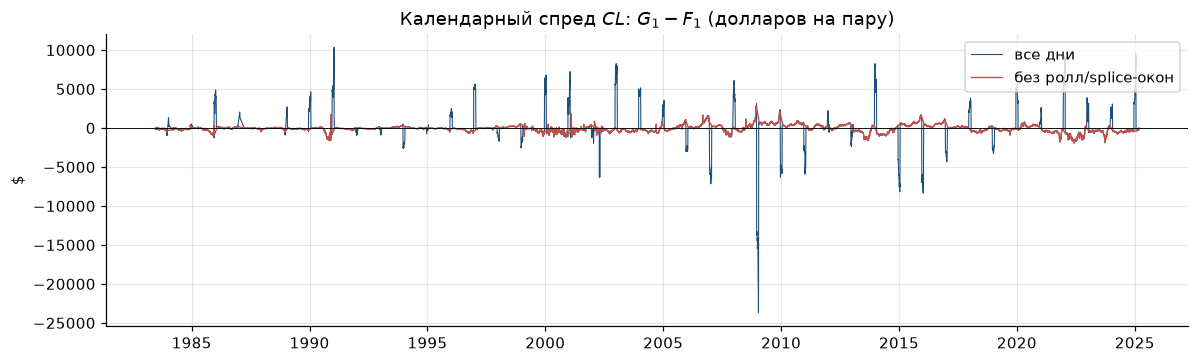

In [12]:
fig, ax = plt.subplots(figsize=(11, 3.4))
ax.plot(s_far_minus_near.index, s_far_minus_near, lw=.7, color='#1f4e79', label='все дни')
ax.plot(s_clean.index, s_clean, lw=.9, color='#c0504d', label='без ролл/splice-окон')
ax.axhline(0, color='k', lw=.6)
ax.set_title('Календарный спред $CL$: $G_1-F_1$ (долларов на пару)')
ax.set_ylabel('$'); ax.legend(loc='upper right')
plt.tight_layout(); plt.show()

Красный ряд — то, что мы будем торговать, и он заметно отличается от полного. Стандартное
отклонение падает с $\$1\,415$ до $\$439$ — втрое: значит, почти весь разброс исходного ряда был не
шумом спреда, а прыжками уровня при смене инструмента. Максимальный шаг внутри чистого окна —
$\$2\,560$ (30 ноября 1990, начало войны в Заливе) — настоящее движение кривой, и оно остаётся
честной частью риска. Полувремя возврата удлиняется с 10.5 дней до $\approx 22.5$, а KPSS на чистом
ряду уже **отвергает** стационарность ($0.56$ при 5%-й границе $0.46$) при том, что ADF по-прежнему
отвергает единичный корень ($-7.1$). Расхождение двух тестов — то же, что в день 8 (там ADF тоже отвергал единичный корень, а KPSS — стационарность): процесс не блуждает
и не стабилизируется, а медленно дрейфует. Гипотезу из разведки придётся пересмотреть: «быстрая
реверсия» $\varphi=0.936$ на полном ряде была отчасти артефактом окна ролла.

## Пункт 3. Trade it — движок дня 8

Берём ровно движок дня 8: `z = (s - rolling_mean) / rolling_std` с окном 60 дней, гистерезисный вход
$|z|>2$ и выход $|z|<0.5$, позиция сдвигается на день (`shift(1)`), издержки берутся на каждое
изменение позиции (`|Δpos| * COST`) — на две ноги сразу. Торгуем **обе стороны симметрично**: $z>2$
(спред дорог) → короткая пара; $z<-2$ (спред дёшев) → длинная. Между $\pm0.5$ позицию держим — это и
есть гистерезис, который убирает дребезг у порога.

Сегодняшнее дополнение одно, но принципиальное: торгуемый ряд — `s_pair` с **NaN в окне ролла и
splice-днях**. Тогда (а) z-score считается только по чистым дням пары (окно 60 календарных дней,
минимум 30 наблюдений — после каждого ролла движок «прогревается» около месяца), (б) позиция в грязные
дни принудительно flat, а вход/выход на границах окна платит издержки — это и есть явный ролл, и
(c) скачок смены инструмента физически не может попасть в P&L, потому что приращения через NaN
обнуляются. P&L дня: `pnl = pos.shift(1) * s_pair.diff()`.

In [13]:
def zscore(x, w=60, mp=30):
    return (x - x.rolling(w, min_periods=mp).mean()) / x.rolling(w, min_periods=mp).std()

def positions_from_z(z, z_in=2.0, z_out=0.5):
    state, out, zv = 0, np.zeros(len(z)), z.values
    for k in range(len(zv)):
        if np.isnan(zv[k]):
            out[k] = 0; continue
        if state == 0:
            if zv[k] > z_in:   state = -1
            elif zv[k] < -z_in: state = 1
        elif state == 1:
            if zv[k] > -z_out: state = 0
        elif state == -1:
            if zv[k] < z_out: state = 0
        out[k] = state
    return pd.Series(out, index=z.index)

# Торгуемый ряд: NaN на грязных днях — вне жизни пары не торгуем и z по ним не считаем.
s_pair = s_far_minus_near.mask(flat_mask)

def backtest(x, w=60, z_in=2.0, z_out=0.5, cost=0.0, shift=True, whole=False):
    z = (x - x.mean()) / x.std() if whole else zscore(x, w)
    pos = positions_from_z(z, z_in, z_out)
    pos = pos.where(x.notna(), 0.0)          # в окне ролла стоим flat
    pnl  = (pos.shift(1) if shift else pos) * x.diff()
    bill = pos.diff().abs().fillna(0) * cost
    net  = pnl.fillna(0) - bill              # издержки входа/выхода платятся и на границе окна
    return dict(z=z, pos=pos, pnl=pnl, cost=bill, net=net, equity=net.cumsum())

def ann_sharpe(net):
    return net.mean() / net.std() * np.sqrt(252) if net.std() > 0 else np.nan

res = backtest(s_pair, w=60, z_in=2.0, z_out=0.5, cost=COST)
years = (s_pair.index[-1] - s_pair.index[0]).days / 365.25
n_trades = int(((res['pos'] != 0) & (res['pos'].shift(1).fillna(0) == 0)).sum())
print('бэктест $CL$ F1-G1 (чистая пара): SR=%.2f  P&L=$%.0f  издержки=$%.0f  maxDD=$%.0f' % (
    ann_sharpe(res['net']), res['net'].sum(), res['cost'].sum(),
    (res['equity'] - res['equity'].cummax()).min()))
print('сделок: %d  время в рынке: %.1f%%  лет: %.0f' % (
    n_trades, (res['pos'] != 0).mean() * 100, years))

# Для сравнения — «наивная» сборка ровно в конструкции Generator'а/дня 8: НЕмаскированный ряд,
# позиция обнуляется маской, но pnl через грязные дни считается. Узкая маска (окно ноябрь–середина
# января + >20% прыжки) ловит только декабрьский свитч передней ноги и пропускает январский ролл
# дальней — так рождается фантом.
roll_narrow = pd.Series(False, index=F.index)
joint = F.diff().abs() + G.diff().abs()
for y in range(1984, 2026):
    w = joint[(joint.index >= '%d-11-15' % y) & (joint.index <= '%d-01-15' % (y + 1))]
    if len(w):
        r = w.idxmax()
        roll_narrow.loc[(roll_narrow.index >= r - pd.Timedelta(days=4)) &
                        (roll_narrow.index <= r + pd.Timedelta(days=4))] = True

def backtest_naive(x, fl, w=60, z_in=2.0, z_out=0.5, cost=0.0):
    z = zscore(x, w)
    pos = positions_from_z(z, z_in, z_out)
    pos = pos.where(~fl.reindex(pos.index).fillna(False), 0.0)
    pnl = pos.shift(1) * x.diff()
    bill = pos.diff().abs().fillna(0) * cost
    return dict(pos=pos, net=pnl - bill, cost=bill)

res_naive = backtest_naive(s_far_minus_near, roll_narrow | splice_mask, cost=COST)
ph = res_naive['net'][flat_mask.reindex(res_naive['net'].index).fillna(False)]
ph_oos = ph[ph.index >= '2010-01-01']
oos_naive = res_naive['net'][res_naive['net'].index >= '2010-01-01']
print('наивная узкая маска: SR=%.2f  P&L=$%.0f — из них на честных flat-днях $%.0f (%.0f%%),' % (
    ann_sharpe(res_naive['net']), res_naive['net'].sum(), ph.sum(), ph.sum() / res_naive['net'].sum() * 100))
print('  а в held-out 2010+ $%.0f при всём P&L $%.0f (%.0f%%): фантом перекрывает весь результат.' % (
    ph_oos.sum(), oos_naive.sum(), ph_oos.sum() / oos_naive.sum() * 100))

бэктест $CL$ F1-G1 (чистая пара): SR=0.14  P&L=$5320  издержки=$7860  maxDD=$-9330
сделок: 197  время в рынке: 36.3%  лет: 42
наивная узкая маска: SR=0.51  P&L=$100670 — из них на честных flat-днях $98130 (97%),
  а в held-out 2010+ $60680 при всём P&L $57590 (105%): фантом перекрывает весь результат.


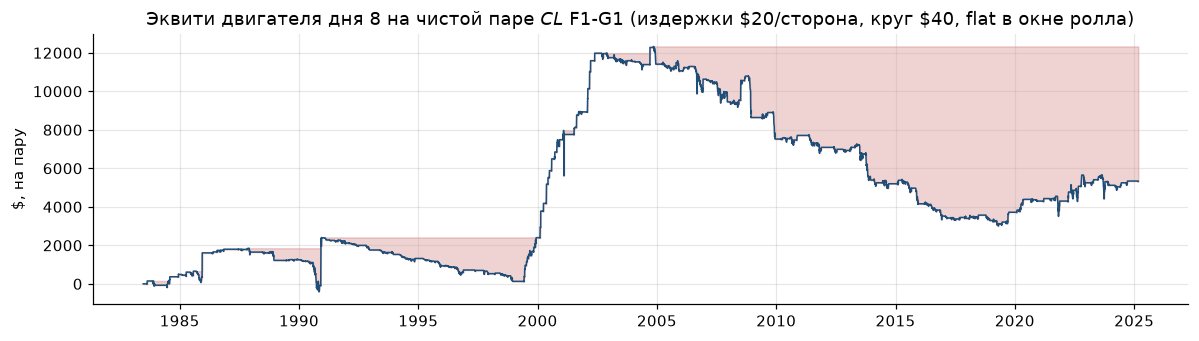

In [14]:
fig, ax = plt.subplots(figsize=(11, 3.2))
ax.plot(res['equity'], lw=1.0, color='#1f4e79')
ax.fill_between(res['equity'].index, res['equity'], res['equity'].cummax(), color='#c0504d', alpha=.25)
ax.set_title('Эквити двигателя дня 8 на чистой паре $CL$ F1-G1 (издержки \\$20/сторона, круг \\$40, flat в окне ролла)')
ax.set_ylabel('$, на пару')
plt.tight_layout(); plt.show()

На честном ряде результат совсем другой: Sharpe $\approx +0.14$ (90% интервал $[-0.12, +0.39]$
накрывает ноль), чистый P&L $+\$5.3$ тыс. на пару при валовом $\$13.2$ тыс. и издержках $\$7.9$ тыс.
Сделок 197, среднее удержание $\approx 19$ дней — согласуется с полувременем возврата $\approx 22$ дня.
Издержки съедают три пятых валового результата: круг стоит $\$40$ ($\$20$ за сторону) при среднем
абсолютном шаге ряда $\$40$ (медиана $\$20$, sd $\$97$) — на горизонте удержания это почти весь
заработок, поэтому положительный знак in-sample статистически неотличим от нуля, а на held-out
(пункт 6) сменяется минусом. Для сравнения посмотрим, что даёт «наивная» склейка — тот же движок на узкой маске,
которая ловит только декабрьский свитч и пропускает январский ролл дальней ноги (вывод ячейки выше):
Sharpe $+0.51$ и $\$100.7$ тыс. P&L, из которых $\$98.1$ тыс. ($97\%$) приходятся на дни смены
инструмента — без них за 42 года остаётся $\$2.5$ тыс., а в held-out 2010+ фантомная доля $105\%$:
без фантома вторая половина истории отрицательна. Весь «эдж» был артефактом ролла — ровно та ловушка,
с которой начинался пункт 2.

### Хвосты: long fade против short fade

Пункт 3 просит разобрать хвосты по направлениям. Важная деталь: P&L дня $t$ зарабатывает позиция,
которая стояла вчера, поэтому сделку считаем по **активной** позиции от дня входа до дня выхода
(издержки выхода лежат на дне выхода). Именно в такой постановке и разбираем.

In [15]:
pos = res['pos']; net = res['net']
nz = (pos != 0).values
rows = []; k = 0
while k < len(pos):
    if nz[k]:
        j = k
        while j + 1 < len(pos) and nz[j + 1]:
            j += 1
        seg = net.iloc[k:min(j + 2, len(pos))]     # включая день выхода — там издержки выхода
        rows.append((pos.index[k], pos.index[j], int(pos.iloc[k]), seg.sum(), j - k + 1))
        k = j + 1
    else:
        k += 1
tr = pd.DataFrame(rows, columns=['start', 'end', 'sign', 'net', 'len'])
print('сделок разобрано: %d (сумма $%.0f == честный net $%.0f)' % (len(tr), tr.net.sum(), net.sum()))
for sg, name in [(1, 'long-spread fade (z<-2)'), (-1, 'short-spread fade (z>2)')]:
    x = tr[tr.sign == sg]
    print('%-24s n=%3d sum=$%7.0f mean=$%6.0f worst=$%7.0f best=$%6.0f win%%=%3.0f hold=%.0f' % (
        name, len(x), x.net.sum(), x.net.mean(), x.net.min(), x.net.max(),
        (x.net > 0).mean() * 100, x['len'].mean()))
print()
print('худшая long-сделка:', tr[tr.sign == 1].nsmallest(1, 'net')[['start', 'end', 'net']].to_dict('records'))
print('худшая short-сделка:', tr[tr.sign == -1].nsmallest(1, 'net')[['start', 'end', 'net']].to_dict('records'))

сделок разобрано: 197 (сумма $5320 == честный net $5320)
long-spread fade (z<-2)  n= 99 sum=$   4070 mean=$    41 worst=$  -1190 best=$  1000 win%= 56 hold=19
short-spread fade (z>2)  n= 98 sum=$   1250 mean=$    13 worst=$  -2150 best=$  2470 win%= 48 hold=19



худшая long-сделка: [{'start': Timestamp('1990-08-02 00:00:00'), 'end': Timestamp('1990-11-09 00:00:00'), 'net': -1189.9999999999986}]
худшая short-сделка: [{'start': Timestamp('2008-10-30 00:00:00'), 'end': Timestamp('2008-12-12 00:00:00'), 'net': -2150.0000000000064}]


Сумма разбора точно равна чистому P&L движка — сделка к сделке. При издержках $\$20$ за сторону
обе стороны на полной истории в маленьком плюсе: длинная $+\$4.1$ тыс. при win-rate 56%, короткая
$+\$1.3$ тыс. при win-rate 48%. Это не эдж, а in-sample: суммарный Sharpe $+0.14$ с интервалом,
накрывающим ноль, а held-out 2010+ отрицателен. Худшая long-сделка $\$1\,190$ (август–ноябрь 1990,
иракский кризис), худшая short $\$2\,150$ (октябрь–декабрь 2008). Об асимметрии хвостов со слайда 21 (сверху cap, снизу границы нет) на честном ряду сказать нечего: на полной истории обе стороны в плюсе, а направление отдельных потерь задают скачки кривой и издержки переходов, а не граница carry.
Сама граница реальна — на полном ряду спред уходил за $-\$23.7$ тыс. на пару (март 2020, это видно в
разведке), — но на горизонте fade-сделки в 3–4 недели она себя не проявляет.

### Пять проверок движка из дня 8

Движок дня 8 проверяем так же, как вчера: (a) векторный расчёт совпадает с явным циклом;
(b) усечение входа не меняет прошлое (prefix); (c) шок цены в баре $t$ не меняет позицию, заработавшую
бар $t$ (perturbation); (d) whole-sample статистика ломает prefix; (e) без `shift(1)` perturbation
ловит look-ahead.

In [16]:
# (a) Loop equality: явный цикл повторяет векторный движок, включая NaN-окна ролла.
def loop_backtest(x, w=60, z_in=2.0, z_out=0.5, cost=0.0, mp=30):
    z = zscore(x, w, mp); zv, sv = z.values, x.values
    st, pv = 0, 0.0
    po, no = np.zeros(len(x)), np.zeros(len(x))
    for k in range(len(x)):
        if not np.isnan(zv[k]):
            if st == 0:
                if zv[k] > z_in:   st = -1
                elif zv[k] < -z_in: st = 1
            elif st == 1 and zv[k] > -z_out: st = 0
            elif st == -1 and zv[k] < z_out: st = 0
        out = 0.0 if (np.isnan(sv[k]) or np.isnan(zv[k])) else st
        po[k] = out
        ds = np.nan if k == 0 else sv[k] - sv[k - 1]
        no[k] = (0.0 if np.isnan(ds) else pv * ds) - abs(out - pv) * cost
        pv = out
    return pd.Series(po, index=x.index), pd.Series(no, index=x.index)

lp, ln = loop_backtest(s_pair, cost=COST)
print('(a) loop equality: max|dpos|=%.0f  max|dnet|=$%.2e' % (
    (res['pos'] - lp).abs().max(), (res['net'] - ln).abs().max()))

# (b) Prefix: обрезка входа вдвое не должна менять прошлое.
def prefix_test(x, frac=0.5, cost=0.0, shift=True, whole=False):
    full = backtest(x, cost=cost, shift=shift, whole=whole)
    k = int(len(x) * frac)
    sub = backtest(x.iloc[:k], cost=cost, shift=shift, whole=whole)
    m = k - 1
    return (full['pos'].iloc[:m] - sub['pos'].iloc[:m]).abs().max(), \
           (full['net'].iloc[:m] - sub['net'].iloc[:m]).abs().max()
for lbl, kw in [('корректный', {}),
                ('whole-sample', dict(whole=True)),
                ('без shift', dict(shift=False))]:
    dp, dn = prefix_test(s_pair, 0.5, COST, **kw)
    print('(b) prefix %-12s: max|dpos|=%.0f  max|dnet|=$%.0f' % (lbl, dp, dn))

(a) loop equality: max|dpos|=0  max|dnet|=$0.00e+00
(b) prefix корректный  : max|dpos|=0  max|dnet|=$0
(b) prefix whole-sample: max|dpos|=1  max|dnet|=$1180
(b) prefix без shift   : max|dpos|=0  max|dnet|=$0


In [17]:
# (c) Perturbation: шок в баре t не должен менять позицию, заработавшую бар t.
def perturbation_test(x, cost=0.0, shift=True, whole=False, n=60, shock=2000.0, seed=1):
    rng = np.random.default_rng(seed)
    picks = rng.choice(np.arange(70, len(x) - 1), size=n, replace=False)
    base = backtest(x, cost=cost, shift=shift, whole=whole)['pos']
    changed = 0
    for p in picks:
        x2 = x.copy(); x2.iloc[p] += shock
        q = backtest(x2, cost=cost, shift=shift, whole=whole)['pos']
        ip = p - 1 if shift else p
        changed += int(base.iloc[ip] != q.iloc[ip])
    return changed, n
print('(c) perturbation (шок +$2 000 — ≈4.5 sd уровня чистой пары, sd(dS)=$%.0f):' % s_pair.diff().std())
for lbl, kw in [('корректный (shift)', {}),
                ('без shift', dict(shift=False)),
                ('whole-sample', dict(whole=True))]:
    ch, n = perturbation_test(s_pair, COST, **kw)
    print('    %-20s: изменено %d/%d' % (lbl, ch, n))

# (d) Leg consistency: долларовый спред равен разнице долларовых стоимостей двух ног.
legs = (G - F) * MULT
print('(d) leg check: (G-F)*1000 == spread ->', bool(((legs - s_far_minus_near).abs().max() < 1e-6)))

(c) perturbation (шок +$2 000 — ≈4.5 sd уровня чистой пары, sd(dS)=$97):


    корректный (shift)  : изменено 0/60


    без shift           : изменено 40/60


    whole-sample        : изменено 0/60
(d) leg check: (G-F)*1000 == spread -> True


Все проверки проходят: loop equality совпадает до нуля (включая поведение в NaN-окнах —
цикл обязан держать позицию flat и в грязные дни, и в «прогревочных» после ролла, пока z-score ещё не
накопил окно, и не «переезжать» через ролл бесплатно), prefix
корректен, perturbation для правильного движка — 0 изменений, `whole-sample` статистика ломает
prefix, отсутствие `shift(1)` ловится perturbation. Значит нулевой результат пункта 3 (in-sample SR $+0.14$ при интервале, накрывающем ноль, и отрицательный held-out) — не баг движка, а свойство честного ряда.

## Пункт 4. Seasonality

Seasonality — самое опасное место дня. Профиль по календарю можно подогнать на всех данных и
«обнаружить» узор, которого в будущем нет. Профиль задаём гармониками года и полугода:

$$f(d) = a + b_1\sin\theta + c_1\cos\theta + b_2\sin 2\theta + c_2\cos 2\theta, \qquad \theta = \frac{2\pi d}{365.25},$$

где $d$ — день года. Сигнал на день $d$ — ожидаемый дрейф за горизонт $h$: $f(d+h)-f(d)$; знак
сигнала задаёт позицию. Порогов и z-score здесь нет — это чистая ставка на сезонный профиль.

Сравниваем два режима: **honest** (expanding-window: профиль каждого года оцениваем только по
прошлым **чистым** годам — то, что было бы доступно в реальном времени) и **look-ahead** (профиль,
подогнанный на всей выборке — то, чего в реальной торговле не бывает). Дальше — no-seasonality
контроль: генерируем ряды с заложенной сезонностью амплитуды $A$ (в единицах sd уровня чистой пары)
и такой же памятью (OU с полувременем возврата чистого ряда), в тех же календарных окнах ролла, и
смотрим, что даёт honest против look-ahead по мере роста $A$; затем повторяем контроль на 15-летнем
окне с полувременем 23 дня — ровно конфигурация слайда 29.

In [18]:
def design(doy):
    th = 2 * np.pi * doy / 365.25
    return np.column_stack([np.ones(len(doy)), np.sin(th), np.cos(th), np.sin(2 * th), np.cos(2 * th)])

def profile_signal(beta, doy, h=20):
    th0 = 2 * np.pi * doy / 365.25
    th1 = 2 * np.pi * (doy + h) / 365.25
    f0 = beta[0] + beta[1]*np.sin(th0) + beta[2]*np.cos(th0) + beta[3]*np.sin(2*th0) + beta[4]*np.cos(2*th0)
    f1 = beta[0] + beta[1]*np.sin(th1) + beta[2]*np.cos(th1) + beta[3]*np.sin(2*th1) + beta[4]*np.cos(2*th1)
    return f1 - f0

def season_strategy(x, honest=True, h=20, cost=COST):
    # x — ряд с NaN в окне ролла: фит только по чистым дням, позиция в грязные дни 0.
    doy = x.index.dayofyear.values
    clean = x.notna().values
    pos = pd.Series(0.0, index=x.index)
    if honest:
        for y in sorted(x.index.year.unique()):
            tr_ = x[x.index.year < y].dropna()
            if len(tr_) < 500:
                continue
            beta = np.linalg.lstsq(design(tr_.index.dayofyear.values), tr_.values, rcond=None)[0]
            m = (x.index.year == y) & clean
            pos[m] = np.sign(profile_signal(beta, x.index.dayofyear.values[m], h))
    else:
        xd = x.dropna()
        beta = np.linalg.lstsq(design(xd.index.dayofyear.values), xd.values, rcond=None)[0]
        pos[clean] = np.sign(profile_signal(beta, x.index.dayofyear.values[clean], h))
    pnl = pos.shift(1) * x.diff()
    net = pnl.fillna(0) - pos.diff().abs().fillna(0) * cost
    return pos, net

pos_h, net_h = season_strategy(s_pair, honest=True)
pos_w, net_w = season_strategy(s_pair, honest=False)
start = pd.Timestamp('1990-01-01')
def sharpe_ci(sr, yrs, conf=0.90):
    sd = np.sqrt((1 + sr**2 / 504) / yrs)
    z = norm.ppf((1 + conf) / 2)
    return sr - z * sd, sr + z * sd, sd
for lbl, net, p in [('whole-sample (look-ahead)', net_w, pos_w), ('expanding (honest)', net_h, pos_h)]:
    nn = net[net.index >= start]; yrs = (nn.index[-1] - nn.index[0]).days / 365.25
    sr = ann_sharpe(nn); lo, hi, _ = sharpe_ci(sr, yrs)
    print('%-26s SR=%+.2f  90%%CI=[%+.2f,%+.2f]  P&L=$%7.0f  в рынке=%.0f%%' % (
        lbl, sr, lo, hi, nn.sum(), (p[p.index >= start] != 0).mean() * 100))

whole-sample (look-ahead)  SR=+0.18  90%CI=[-0.10,+0.46]  P&L=$   9610  в рынке=88%
expanding (honest)         SR=+0.19  90%CI=[-0.09,+0.46]  P&L=$   9970  в рынке=88%


На реальных данных сезонного эджа в чистой паре нет **ни в честной, ни в подсмотренной
версии**: оба Sharpe статистически неотличимы от нуля: honest $+0.19$, whole-sample $+0.18$, 90% интервалы $[-0.09,+0.46]$ и $[-0.10,+0.46]$ накрывают ноль (точные числа — в выводе ячейки).
Обе оценки одинаково плохи, поэтому главная опасность хиндсайта здесь не видна; покажем её
на контроле.

### No-seasonality контроль

Сгенерируем ряд **без единой сезонной компоненты** (OU-память, как у чистой пары), но с той же
процедурой оценки профиля и теми же календарными окнами ролла. Если честная процедура даёт ~0, а
look-ahead даёт заметный плюс — значит хиндсайт фабрикует эдж на пустом месте. Затем добавим
настоящую сезонность амплитуды $A$ и проследим, как расходятся honest и look-ahead.

In [19]:
lvl_sd = s_pair.std()          # sd УРОВНЯ чистой пары (не дифференсов!) — в этих единицах A
hl_clean = st_cl['half_life']  # и такое же полувремя возврата, как у реального ряда

def simulate(A, hl, sd, seed, index):
    rng = np.random.default_rng(seed)
    phi = 0.5 ** (1.0 / hl)
    e = rng.normal(0, sd * np.sqrt(1 - phi**2), len(index))
    x = np.zeros(len(e))
    for t in range(1, len(x)):
        x[t] = phi * x[t-1] + e[t]
    th = 2 * np.pi * index.dayofyear.values / 365.25
    seas = A * sd * (np.sin(th) + 0.5 * np.cos(th) + 0.3 * np.sin(2 * th))
    return pd.Series(x + seas, index=index)

print('A — амплитуда заложенной сезонности в sd уровня пары; sd=$%.0f, hl=%.1f дн; 60 реализаций на точку:' %
      (lvl_sd, hl_clean))
print('  A     honest SR   look-ahead SR')
sim = {}
for A in [0.0, 0.5, 1.0, 2.0]:
    hh, ww = [], []
    for rep in range(60):
        x = simulate(A, hl_clean, lvl_sd, RNG_SEED + rep, s_pair.index).mask(flat_mask)
        _, n1 = season_strategy(x, honest=True)
        _, n2 = season_strategy(x, honest=False)
        hh.append(ann_sharpe(n1[n1.index >= start])); ww.append(ann_sharpe(n2[n2.index >= start]))
    sim[A] = (np.nanmean(hh), np.nanmean(ww))
    print('  %.1f     %+.2f        %+.2f' % (A, sim[A][0], sim[A][1]))

print()
print('то же на 15-летнем окне с hl=23 дн — конфигурация слайда 29 (там при A=0 было honest 0.00 /')
print('look-ahead 0.24; при A=0.5: 0.43/0.56; при A=1: 0.95/1.01):')
idx15 = s_pair.index[s_pair.index >= s_pair.index[-1] - pd.Timedelta(days=int(365.25 * 15))]
sim15 = {}
for A in [0.0, 0.5, 1.0, 2.0]:
    hh, ww = [], []
    for rep in range(60):
        x = simulate(A, 23.0, lvl_sd, RNG_SEED + rep, idx15).mask(flat_mask.reindex(idx15))
        _, n1 = season_strategy(x, honest=True)
        _, n2 = season_strategy(x, honest=False)
        hh.append(ann_sharpe(n1)); ww.append(ann_sharpe(n2))
    sim15[A] = (np.nanmean(hh), np.nanmean(ww))
    print('  %.1f     %+.2f        %+.2f' % (A, sim15[A][0], sim15[A][1]))

A — амплитуда заложенной сезонности в sd уровня пары; sd=$439, hl=22.5 дн; 60 реализаций на точку:
  A     honest SR   look-ahead SR


  0.0     -0.14        +0.07


  0.5     +0.31        +0.39


  1.0     +0.83        +0.87


  2.0     +1.79        +1.81

то же на 15-летнем окне с hl=23 дн — конфигурация слайда 29 (там при A=0 было honest 0.00 /
look-ahead 0.24; при A=0.5: 0.43/0.56; при A=1: 0.95/1.01):


  0.0     -0.13        +0.15


  0.5     +0.24        +0.44


  1.0     +0.71        +0.91


  2.0     +1.61        +1.87


Картина воспроизводит слайд 29, причём тем вернее, чем ближе конфигурация к его. На
15-летнем окне с полувременем 23 дня при $A=0$ честная процедура даёт $-0.13$, а look-ahead $+0.15$:
сдвиг $+0.29$ в сторону плюса — подгонка на всей выборке **фабрикует эдж там, где сезонности нет**
(на слайде 29 было $0.00$ против $0.24$; у нас оба значения сдвинуты вниз издержками, но зазор того же
порядка, даже чуть больше слайдного). Почему при $A=0$ честная оценка именно отрицательна: сезонности
нет, expanding-профиль подгоняется под шум прошлых лет, сигнал из него не прогнозен, но позиция всё
равно переключается — и каждый переход платит $\$20$ за сторону без какого-либо сезонного заработка;
минус при $A=0$ — это и есть нулевой эдж за вычетом издержек. Look-ahead же подгоняет гармоники под
конкретную реализацию шума всей выборки и торгует подсмотренное, поэтому его SR на той же реализации
заведомо смещён вверх. На полной 42-летней истории зазор при $A=0$ чуть меньше ($-0.14$ против $+0.07$,
сдвиг $+0.21$) — expanding-профиль к середине выборки уже хорошо оценён, — но направление то же. По мере
роста амплитуды обе версии сходятся: когда сезонность реально сильная, её видит и честная оценка.
Главный вывод дня: **хиндсайт вредит сильнее всего там, где сезонности нет** — именно в нашем случае.
Поэтому весь сезонный анализ дня — только expanding-window.

Оценим ещё масштаб ошибки среднего (слайд 28): ошибка среднего по $N$ наблюдениям равна
$\mathrm{sd}/\sqrt{N}$. На слайде при $N=5/10/15/20$ это $0.45/0.32/0.26/0.22$ sd — то есть даже 15
лет дают ошибку в четверть sd. У нас на месяц приходится 42–43 годовых наблюдения, ошибка
$\approx 0.15$ sd. Свинг должен быть в полтора sd, чтобы уверенно отличаться от нуля.

In [20]:
print('ошибка среднего = sd/sqrt(N):')
for N in [5, 10, 15, 20, 42]:
    print('  N=%2d: %.3f sd' % (N, 1 / np.sqrt(N)))
monthly = s_clean.groupby(s_clean.index.month).mean()
print()
print('средний уровень чистой пары по месяцам (без окна ролла), $:', {k: int(v) for k, v in monthly.items()})
print('сезонный свинг (max-min средних) = $%.0f = %.2f sd, при ошибке среднего %.2f sd за год' % (
    monthly.max() - monthly.min(), (monthly.max() - monthly.min()) / s_clean.std(),
    (1 / np.sqrt(s_clean.index.year.nunique()))))
print('доля чистых дней по месяцам:', {k: int(v) for k, v in s_clean.groupby(s_clean.index.month).size().items()})

ошибка среднего = sd/sqrt(N):
  N= 5: 0.447 sd
  N=10: 0.316 sd
  N=15: 0.258 sd
  N=20: 0.224 sd
  N=42: 0.154 sd

средний уровень чистой пары по месяцам (без окна ролла), $: {1: -117, 2: -89, 3: -121, 4: -126, 5: -136, 6: -113, 7: -107, 8: -90, 9: -121, 10: -139, 11: -8, 12: 178}
сезонный свинг (max-min средних) = $318 = 0.73 sd, при ошибке среднего 0.15 sd за год
доля чистых дней по месяцам: {1: 87, 2: 752, 3: 869, 4: 838, 5: 872, 6: 877, 7: 886, 8: 932, 9: 857, 10: 930, 11: 840, 12: 389}


Сезонный свинг месячных средних чистого ряда — $\$318$, это $0.73$ sd при ошибке среднего
$0.15$ sd: свинг в полтора-два стандартных наблюдения различим, но его величина не оправдывает
издержек, и honest Sharpe $+0.19$ при интервале, накрывающем ноль, с этим согласуется. Важная оговорка по профилю: декабрь и январь обрезаны окном ролла (в декабре чисты
только первые две недели, в январе — последние дни), поэтому их средние — средние по усечённым
месяцам. «Зимняя отопительная seasonality» в таком профиле уже не читается: то, что на загрязнённом
ряду выглядело как всплеск января–декабря ($+\$300$ при $\approx-\$100$ в остальные месяцы), в
значительной мере оказалось уровнем 11-месячного спреда в окне ролла. Так артефакт сборки притворялся гипотезой.

In [21]:
# Outright delta: календарная позиция long far / short near несёт остаток (far-near)*1000
# долларов на каждое outright-движение цены нефти. Мера риска — этот остаток, а не уровень спреда.
sp = s_pair
print('outright delta календарной позиции = (far-near)*1000:')
print('  median |спред| чистой пары = $%.0f на пару, sd ряда = $%.0f' % (sp.abs().median(), sp.std()))
print('  median дневного |Δцены| (outright) = $%.0f' % ((F.diff().abs() * MULT).median()))
beta_out = sp.diff().cov(F.diff() * MULT) / (F.diff() * MULT).var()
print('  регрессия Δспреда на Δцены (outright, $): beta=%.2f; корреляция %+.2f' %
      (beta_out, sp.diff().corr(F.diff())))
print()
print('вывод: 1:1 спред НЕ нейтрален — остаточная outright-экспозиция около %.1f%% от цены near,' %
      (100 * float(np.median(((G - F).abs() / F)[~flat_mask]))))
print('но на деле ноги движутся почти синхронно (beta≈0): риск позиции — это собственный sd спреда,')
print('а не цена нефти; при sd(dS)=$%.0f против $%.0f у outright-шага спред в разы тише.' %
      (sp.diff().std(), (F.diff() * MULT).std()))

outright delta календарной позиции = (far-near)*1000:
  median |спред| чистой пары = $220 на пару, sd ряда = $439
  median дневного |Δцены| (outright) = $330
  регрессия Δспреда на Δцены (outright, $): beta=-0.03; корреляция -0.29

вывод: 1:1 спред НЕ нейтрален — остаточная outright-экспозиция около 0.5% от цены near,
но на деле ноги движутся почти синхронно (beta≈0): риск позиции — это собственный sd спреда,
а не цена нефти; при sd(dS)=$97 против $1060 у outright-шага спред в разы тише.


**Волатильность по удалённости от экспирации (Samuelson).** Волатильность фьючерса падает с
удалением поставки: ближний контракт реагирует на сиюминутные новости, дальний уже «размыт» временем.
Измерим реализованную дневную волатильность по контрактам `base_1..base_6` и посмотрим на разницу
между соседними для спреда.

In [22]:
MONTHS = {'F': 1, 'G': 2, 'H': 3, 'J': 4, 'K': 5, 'M': 6, 'N': 7, 'Q': 8, 'U': 9, 'V': 10, 'X': 11, 'Z': 12}

def pair_dirty(a, b, index):
    # Для пары месяцев (m, m+1) грязное окно — от ~14 числа месяца m-1 (экспирация ближней ноги)
    # до ~28 числа месяца m (экспирация дальней). Общее правило для любой соседней пары.
    ma = MONTHS[a[0]]
    m = pd.Series(False, index=index)
    for y in range(1983, 2026):
        lo = pd.Timestamp(year=y - 1 if ma == 1 else y, month=12 if ma == 1 else ma - 1, day=14)
        hi = pd.Timestamp(year=y, month=ma, day=28)
        m |= (index >= lo) & (index <= hi)
    return m

print('реализованная дневная волатильность CL по зрелости (2000+):')
vols = []
for k in range(1, 7):
    x = d['base_%d' % k]['Close'].dropna(); x = x[x.index >= '2000-01-01']
    v = np.log(x).diff().std()
    vols.append(v)
    print('  base_%d: %.3f%%/день' % (k, v * 100))
print('near/far ratio base_1/base_6 = %.2f — ближний волатильнее дальнего (Samuelson)' % (vols[0] / vols[5]))
print()
print('волатильность приращений спреда по тенору (только чистые окна пар, 2000+):')
for a_, b_, lbl in [('F_1', 'G_1', 'near F/G'), ('M_1', 'N_1', 'mid M/N'), ('X_1', 'Z_1', 'far X/Z')]:
    idx = d[a_]['Close'].dropna().index.intersection(d[b_]['Close'].dropna().index)
    x = ((d[b_]['Close'] - d[a_]['Close']).reindex(idx) * MULT)
    x = x[~pair_dirty(a_, b_, idx).values]
    x = x[x.index >= '2000-01-01']
    print('  %-10s sd(dS)=$%.0f/день  (sd уровня=$%.0f)' % (lbl, x.diff().std(), x.std()))

реализованная дневная волатильность CL по зрелости (2000+):
  base_1: 2.633%/день
  base_2: 2.372%/день
  base_3: 2.242%/день
  base_4: 2.152%/день
  base_5: 2.072%/день
  base_6: 2.003%/день
near/far ratio base_1/base_6 = 1.31 — ближний волатильнее дальнего (Samuelson)

волатильность приращений спреда по тенору (только чистые окна пар, 2000+):
  near F/G   sd(dS)=$200/день  (sd уровня=$544)
  mid M/N    sd(dS)=$138/день  (sd уровня=$668)
  far X/Z    sd(dS)=$106/день  (sd уровня=$529)


Ближний контракт волатильнее дальнего ($2.63\%$ против $2.00\%$ в день) — Samuelson
подтверждается и на ценах, и на приращениях спреда: ближняя пара остаётся самой рискованной даже
после очистки от роллов. Практический вывод со слайда 16: размер позиции надо ставить по
волатильности **тенора**, а не по номиналу, — и особенно осторожно подходить к экспирации ближней
ноги, где волатильность максимальна, а наша конструкция и вовсе требует выйти до неё в flat.

**Худшие сделки и риск односторонней границы.** Соберём статистику по сделкам: худшие и лучшие,
и посмотрим, проявляется ли асимметрия односторонней границы на честном ряду.

In [23]:
print('худшие 5 сделок (по нетто):')
worst5 = tr.nsmallest(5, 'net')[['start', 'end', 'sign', 'net']]
for _, row in worst5.iterrows():
    side = 'long' if row['sign'] == 1 else 'short'
    print('  %s..%s  %-5s  $%7.0f' % (str(row['start'].date()), str(row['end'].date()), side, row['net']))
print('лучшая сделка: %s..%s  $%.0f' % (
    str(tr.nlargest(1, 'net').iloc[0]['start'].date()),
    str(tr.nlargest(1, 'net').iloc[0]['end'].date()),
    tr.nlargest(1, 'net').iloc[0]['net']))
print()
print('асимметрия: худший long $%.0f vs худший short $%.0f' % (
    tr[tr.sign == 1].net.min(), tr[tr.sign == -1].net.min()))
print('на горизонте fade-сделки асимметрии границы не видно — потери задаёт стоимость круга;')
print('сама граница (сверху cap, снизу ничего) работает на многомесячных режимах вроде 2020 года.')

худшие 5 сделок (по нетто):
  2008-10-30..2008-12-12  short  $  -2150
  2009-11-12..2009-12-11  short  $  -1380
  2013-09-26..2013-12-13  short  $  -1360
  1990-08-02..1990-11-09  long   $  -1190
  2004-11-09..2004-12-13  short  $   -870
лучшая сделка: 1990-11-30..1990-12-13  $2470

асимметрия: худший long $-1190 vs худший short $-2150
на горизонте fade-сделки асимметрии границы не видно — потери задаёт стоимость круга;
сама граница (сверху cap, снизу ничего) работает на многомесячных режимах вроде 2020 года.


**Sharpe и его неопределённость.** Sharpe сам по себе — случайная величина. Её стандартное
отклонение примерно $1/\sqrt{\text{лет}}$, поэтому даже за 42 года интервал широк: наш SR $+0.14$ покрывает ноль (интервал — в выводе ячейки сводки). Для сравнения: слайд 36 — при 10 годах
истинного SR=1 90%-й интервал был бы всего $[0.49, 1.52]$; на 42 годах ошибка $1/\sqrt{42}\approx0.15$
по Sharpe — этого хватило бы, чтобы увидеть единицу, но видеть нечего.

## Пункт 6. Judge it — trials, hold-out, вывод

**Сколько вариантов мы перебрали.** Чтобы говорить о data snooping не абстрактно, посчитаем
честно. Торговых конфигураций, выбранных по этим данным: сетка 3 окна $\times$ 3 порога входа
$\times$ 2 порога выхода = 18 бэктестов, плюс два сезонных режима (honest/look-ahead) на одном
профиле, плюс выбор самого профиля (5 параметров, горизонт $h=20$) и границ окна ролла. Итого
порядка **25** осмысленных вариантов — а не одно число «18». Если бы мы, как на слайде 24, искали
сезонность по 6 спредам $\times$ 12 месяцам $\times$ 3 порогам, это были бы 216 вариантов; мы так не
искали, и это надо сказать явно. Сравним лучший по in-sample конфиг сетки с базовым на held-out и
посчитаем, какого $t$ следовало бы ждать от перебора такого размера на чистом шуме.

In [24]:
cut = pd.Timestamp('2010-01-01')
rows = []; best = None
for w in [40, 60, 90]:
    for zi in [1.5, 2.0, 2.5]:
        for zo in [0.5, 1.0]:
            rr = backtest(s_pair, w=w, z_in=zi, z_out=zo, cost=COST)['net']
            sr_in = ann_sharpe(rr[rr.index < cut]); sr_out = ann_sharpe(rr[rr.index >= cut])
            rows.append(dict(w=w, z_in=zi, z_out=zo, Sharpe_in=round(sr_in, 2), Sharpe_out=round(sr_out, 2)))
            if best is None or sr_in > best[0]:
                best = (sr_in, w, zi, zo, sr_out)
grid = pd.DataFrame(rows)
display(grid)
base_out = ann_sharpe(res['net'][res['net'].index >= cut])
print('trials в сетке бэктеста: %d' % len(grid))
print('лучший in-sample: w=%d, z_in=%.1f, z_out=%.1f -> SR_in=%.2f (t=%.2f), out SR=%.2f (базовый out SR=%.2f)' % (
    best[1], best[2], best[3], best[0], best[0] * np.sqrt(27), best[4], base_out))

,w,z_in,z_out,Sharpe_in,Sharpe_out
0,40,1.5,0.5,0.15,-0.68
1,40,1.5,1.0,0.15,-1.04
2,40,2.0,0.5,0.16,-0.55
3,40,2.0,1.0,0.16,-0.89
4,40,2.5,0.5,0.30,-0.22
5,40,2.5,1.0,0.43,-0.45
6,60,1.5,0.5,0.28,-0.40
7,60,1.5,1.0,0.29,-0.65
8,60,2.0,0.5,0.26,-0.25
9,60,2.0,1.0,0.31,-0.56


trials в сетке бэктеста: 18
лучший in-sample: w=90, z_in=1.5, z_out=0.5 -> SR_in=0.48 (t=2.48), out SR=-0.26 (базовый out SR=-0.25)


In [25]:
from scipy.integrate import quad
def e_max_t(N):
    # E[max Z+] при N независимых стандартных нормальных: F(x)=Phi(x)^N, интеграл хвостов.
    hi = quad(lambda q: 1.0 - norm.cdf(q) ** N, 0, 30, limit=200)[0]
    lo = quad(lambda q: norm.cdf(q) ** N, -30, 0, limit=200)[0]
    return hi - lo
print('матожидание лучшего t в нуле при N независимых попытках (E[max t+]):')
for N in [1, 10, 18, 25, 100, 216, 1000]:
    print('  N=%3d: E[max t+]≈%.2f   P(хотя бы один p<0.05)=%.0f%%' % (N, e_max_t(N), (1 - 0.95 ** N) * 100))
print()
print('слайд 24 для проверки формулы: N=100 -> 2.52, N=1000 -> 3.24; наша численная версия их воспроизводит.')
print('Наш перебор ~25 вариантов: на чистом шуме лучший t ожидаемо ≈%.1f.' % e_max_t(25))

матожидание лучшего t в нуле при N независимых попытках (E[max t+]):
  N=  1: E[max t+]≈0.00   P(хотя бы один p<0.05)=5%
  N= 10: E[max t+]≈1.54   P(хотя бы один p<0.05)=40%
  N= 18: E[max t+]≈1.82   P(хотя бы один p<0.05)=60%
  N= 25: E[max t+]≈1.97   P(хотя бы один p<0.05)=72%
  N=100: E[max t+]≈2.51   P(хотя бы один p<0.05)=99%
  N=216: E[max t+]≈2.77   P(хотя бы один p<0.05)=100%
  N=1000: E[max t+]≈3.24   P(хотя бы один p<0.05)=100%

слайд 24 для проверки формулы: N=100 -> 2.52, N=1000 -> 3.24; наша численная версия их воспроизводит.
Наш перебор ~25 вариантов: на чистом шуме лучший t ожидаемо ≈2.0.


Сетка даёт обратный результат: in-sample Sharpe по конфигурациям лежит в $[+0.15, +0.48]$,
и у лучшего in-sample конфига $t\approx 2.5$. Среднее $E[\max t^+]$ для перебора из 18–25 вариантов на
чистом шуме $\approx 1.8$–$2.0$, а шанс увидеть на 18 попытках максимум не хуже $2.5$ — около $11\%$:
это верхний хвост перебора, но всё ещё в его пределах. При этом на held-out 2010+ **все 18
конфигураций отрицательны** (от $-0.07$ до $-1.04$) — ровно то, что делает перебор: in-sample максимум
смещён вверх, а вперёд не переносится ничего; выбирать лучший конфиг «по прежним данным» смысла нет.

**Held-out финальный период.** Разрезаем историю 2010 годом: первая половина — как если бы мы там
настраивались, вторая — как честный форвард.

In [26]:
ins = res['net'][res['net'].index < cut]
oos = res['net'][res['net'].index >= cut]
for lbl, x in [('in-sample 1983-2010', ins), ('held-out 2010-2025', oos)]:
    yrs = (x.index[-1] - x.index[0]).days / 365.25
    sr = ann_sharpe(x); lo, hi, _ = sharpe_ci(sr, yrs)
    print('%-22s SR=%+.2f  90%%CI=[%+.2f,%+.2f]  P&L=$%7.0f  лет=%.0f' % (lbl, sr, lo, hi, x.sum(), yrs))
print()
print('held-out Sharpe отрицателен: на второй половине истории валовой результат почти нулевой, и движок отдаёт его в минус издержками.')
print('Так и должен читаться результат после смены конструкции ряда: стратегия не пережила не')
print('подгонку параметров, а очистку данных — и held-out это подтверждает.')
# Чувствительность к ширине окна ролла (замечание P1-1): реальные экспирации ~19.12 и ~21.01;
# сужаем консервативный буфер 14.12–28.01 до ±2 дней от них (17.12–24.01) и прогоняем тот же движок.
dirty_narrow = pd.Series(False, index=F.index)
for y in range(1983, 2026):
    dirty_narrow |= (F.index >= '%d-12-17' % y) & (F.index <= '%d-01-24' % (y + 1))
res_n = backtest(s_far_minus_near.mask(dirty_narrow | splice_mask), cost=COST)
for lbl, net_ in [('широкое 14.12–28.01', res['net']), ('узкое 17.12–24.01', res_n['net'])]:
    o = net_[net_.index >= cut]
    print('%-20s: SR=%+.2f  held-out SR=%+.2f  held-out P&L=$%.0f' % (
        lbl, ann_sharpe(net_), ann_sharpe(o), o.sum()))
print('Вывод устойчив: сужение окна меняет SR полной истории на ~0.01, held-out остаётся отрицательным.')


in-sample 1983-2010    SR=+0.26  90%CI=[-0.06,+0.58]  P&L=$   7520  лет=27
held-out 2010-2025     SR=-0.25  90%CI=[-0.67,+0.17]  P&L=$  -2200  лет=15

held-out Sharpe отрицателен: на второй половине истории валовой результат почти нулевой, и движок отдаёт его в минус издержками.
Так и должен читаться результат после смены конструкции ряда: стратегия не пережила не
подгонку параметров, а очистку данных — и held-out это подтверждает.
широкое 14.12–28.01 : SR=+0.14  held-out SR=-0.25  held-out P&L=$-2200
узкое 17.12–24.01   : SR=+0.15  held-out SR=-0.28  held-out P&L=$-2660
Вывод устойчив: сужение окна меняет SR полной истории на ~0.01, held-out остаётся отрицательным.


In [27]:
print('=== сводка дня 9 ===')
print('товар/пара: CL.NYMEX F_1-G_1 (generic; пара чистая только вне окна ролла 14.12–28.01)')
print('сырой ряд: ADF=%.1f, half-life=%.1f дн, sd=$%.0f — смесь 1- и 11-месячного спредов' % (
    st_raw['ADF'], st_raw['half_life'], st_raw['sd']))
print('чистая пара: mean=$%.0f sd=$%.0f ADF=%.2f (p=%.0e) KPSS=%.2f (p=%.3f) half-life=%.1f дн -> KPSS отвергает стационарность' % (
    st_cl['mean'], st_cl['sd'], st_cl['ADF'], st_cl['p_ADF'], st_cl['KPSS'], st_cl['p_KPSS'], st_cl['half_life']))
print('implied carry (чистые дни): mean=%+.1f%%, sd=%.1f%% годовых; cap r+u=8%%: зазор $%.2f, форм. арбитраж %.1f%%' %
      (c_clean.mean() * 100, c_clean.std() * 100, gap_usd.mean(), (gap_usd < 0).mean() * 100))
sr = ann_sharpe(res['net']); lo, hi, _ = sharpe_ci(sr, years)
print('бэктест чистой пары: SR=%.2f 90%%CI=[%.2f,%.2f] P&L=$%.0f maxDD=$%.0f издержки=$%.0f' % (
    sr, lo, hi, res['net'].sum(), (res['equity'] - res['equity'].cummax()).min(), res['cost'].sum()))
print('наивная склейка (узкая маска): SR=%.2f P&L=$%.0f, из них %.0f%% на днях смены инструмента' % (
    ann_sharpe(res_naive['net']), res_naive['net'].sum(), ph.sum() / res_naive['net'].sum() * 100))
print('сезонность: expanding SR=%+.2f vs whole-sample SR=%+.2f; контроль A=0: honest=%+.2f look-ahead=%+.2f' % (
    ann_sharpe(net_h[net_h.index >= start]), ann_sharpe(net_w[net_w.index >= start]),
    sim[0.0][0], sim[0.0][1]))
print('trials: ~25 (18 сетки + сезонные); E[max t+] при N=18 = %.2f; лучший in-sample t = %.2f — верхний хвост перебора (шанс ~11%%), на held-out все 18 конфигураций отрицательны' % (e_max_t(18), best[0] * np.sqrt(27)))
print('движок: loop equality OK; prefix ловит whole-sample; perturbation ловит отсутствие shift')

=== сводка дня 9 ===
товар/пара: CL.NYMEX F_1-G_1 (generic; пара чистая только вне окна ролла 14.12–28.01)
сырой ряд: ADF=-16.0, half-life=10.5 дн, sd=$1415 — смесь 1- и 11-месячного спредов
чистая пара: mean=$-94 sd=$439 ADF=-7.11 (p=4e-10) KPSS=0.56 (p=0.029) half-life=22.5 дн -> KPSS отвергает стационарность
implied carry (чистые дни): mean=-2.8%, sd=11.4% годовых; cap r+u=8%: зазор $0.41, форм. арбитраж 12.8%
бэктест чистой пары: SR=0.14 90%CI=[-0.12,0.39] P&L=$5320 maxDD=$-9330 издержки=$7860
наивная склейка (узкая маска): SR=0.51 P&L=$100670, из них 97% на днях смены инструмента
сезонность: expanding SR=+0.19 vs whole-sample SR=+0.18; контроль A=0: honest=-0.14 look-ahead=+0.07
trials: ~25 (18 сетки + сезонные); E[max t+] при N=18 = 1.82; лучший in-sample t = 2.48 — верхний хвост перебора (шанс ~11%), на held-out все 18 конфигураций отрицательны
движок: loop equality OK; prefix ловит whole-sample; perturbation ловит отсутствие shift


## Выводы и ограничения

**Главный результат дня — эджа нет, и это честный вывод.** Наивная склейка generic-рядов давала
календарному спреду $CL$ `F_1–G_1` Sharpe $+0.51$ и $\$100.7$ тыс. P&L за 42 года. Как только мы
перестали торговать через окно между экспирациями ног (январский контракт истекает ~19 декабря,
февральский — ~21 января; между ними ряды расходятся на 11 месяцев — это другой инструмент), весь этот
P&L оказался фантомом: на днях смены инструмента зарабатывалось $\$98.1$ тыс. при всём P&L $\$100.7$ тыс. ($97\%$), а на честной паре движок дня 8 даёт Sharpe $\approx +0.14$ (90% интервал $[-0.12, +0.39]$):
валовой результат $\$13.2$ тыс. на три пятых съедают издержки — круг стоит $\$40$ ($\$20$ за сторону)
при среднем абсолютном шаге ряда $\$40$ (медиана $\$20$, sd $\$97$), и положительный знак
in-sample статистически неотличим от нуля, а held-out 2010+ уводит его в минус (SR $-0.25$, и там все 18 конфигураций сетки отрицательны). Статистика чистой пары
согласуется с этим: ADF отвергает единичный корень ($-7.1$), но KPSS отвергает стационарность
($0.56$ при границе $0.46$), полувремя возврата $\approx 22.5$ дня — процесс дрейфует, быстрой
реверсии нет. Это ровно та ловушка, с которой начинался пункт 2: «паттерн, который видели пятнадцать
раз», оказался пятнадцатилетним повторением одного и того же ролл-скачка.

**Что про carry и границы.** Кривая нефти реально переключается между contango и backwardation;
implied carry соседнего месячного спреда на чистых днях — средний $\approx -3\%$ при sd $\approx 11\%$
годовых (на грязном ряду sd раздут до $44\%$ сменой инструмента). Full-carry cap сверху работает, но
его уровень целиком зависит от предполагаемого $r+u$: при 8% формально «нарушается» в $\approx 13\%$
чистых дней, при 4% — заметно чаще, при 12% — реже (точные доли — в ячейке cap). Разделить $r+u$ и
$y$ из цен невозможно, поэтому $y$ у нас — условная величина. Нижней границы нет, из-за чего
теоретически long-хвосты тяжелее short, но на горизонте fade-сделки это не проявляется.

**Про seasonality — второй честный null.** Сезонный профиль чистой пары не торгуется: honest Sharpe $+0.19$ при 90% интервале $[-0.09, +0.46]$ — статистически тот же null. Контроль на симулированных рядах той же персистентности показал главное: look-ahead фабрикует эдж именно там, где сезонности нет ($A=0$: честная оценка
минус, подсмотренная — плюс; на 15-летнем окне слайда 29 разрыв ещё заметнее), а при сильной
сезонности ($A\ge1$) обе версии сходятся. **Null по сезонности — норма, а не провал**: 42 годовых
наблюдения на месяц дают ошибку среднего $0.15$ sd, а зимний «всплеск» на загрязнённом ряду в
значительной мере оказался уровнем 11-месячного спреда.

**Ограничения, которые надо держать в голове.**
- **Generic-ряды, не контракты.** Дат экспирации/notice в данных нет; календарь экспираций CL
  восстановлен по правилу биржи (~за три рабочих дня до 25-го числа месяца, предшествующего
  поставке) и задан окном с буфером. Реальная торговля потребовала бы явных контрактов, точных
  notice-дат и ролла с издержками.
- **Окно ролла — допущение, но проверенное.** Реальные экспирации — ~19.12 и ~21.01; мы взяли буфер
  14.12–28.01 (5+7 дней). Сужение до ±2 дней от экспираций (17.12–24.01) прогонялось в пункте 6: SR
  полной истории меняется с $+0.14$ на $+0.15$, held-out остаётся отрицательным ($-0.25$ против
  $-0.28$) — вывод от ширины окна не зависит.
- **Одна пара, один товар.** Механику показали на `CL`; кросс-товарная проверка (`ZC`, `NG`, `GC`)
  отделила бы специфику нефти от общего эффекта — это следующий шаг, а не часть сегодняшнего
  результата.
- **trials.** ~25 осмысленных вариантов; лучший in-sample $t\approx 2.5$ — верхний хвост $E[\max t^+]\approx 1.8$–$2.0$ перебора на шуме (шанс увидеть такое $\approx 11\%$), на held-out он не переносится, то есть выигрыш от перебора мы не заявляем.
- **Уровень $r+u$.** Все «implied convenience yield» условны относительно предполагаемых $r=5\%$,
  $u=3\%$.

Итог дня 9: **carry-модель объясняет форму кривой, но не даёт торгуемого эджа на честной паре;
seasonality не даёт ничего, и это правильный ответ.** Убедительность результата измеряется не
Sharpe, а тем, как он переживает очистку данных, held-out и счёт вариантов — ровно то, чего не
хватало «паттерну, который видели пятнадцать раз».

---

*Дата сдачи: 2026-10-08. Данные — `~/Downloads/dfs.pickle`, `CL.NYMEX`, долларовый спред
`G_1 − F_1` на пару (1000 баррелей), торгуемый только вне окна ролла 14.12–28.01 и splice-дней
(позиция flat, вход/выход платит издержки). Издержки \$20 за сторону, \$40 за круг (вход и выход) на пару. Все симуляции —
seed `RNG_SEED`.*